# Part 1 — Neural Network Fundamentals and Training Behavior Analysis

**Problem:** Binary classification — predict whether a telecom customer will churn (`churn = 1`) or be retained (`churn = 0`).

**Dataset:** `customer_churn_nn.csv` (2,000 rows × 17 columns)

**Approach:** Feed-forward neural network built in TensorFlow / Keras, with hyperparameter experimentation.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Folder for output artefacts (charts, comparison tables)
os.makedirs('results', exist_ok=True)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## Task 1 — Dataset Understanding

In [2]:
df = pd.read_csv('customer_churn_nn.csv')

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
df.head()

Shape: (2000, 17)

Dtypes:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print('=== Missing Value Check ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() else 'No missing values across any column.')

print('\n=== Statistical Summary (numerical) ===')
df.describe().round(2)

=== Missing Value Check ===
No missing values across any column.

=== Statistical Summary (numerical) ===


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


=== Target Variable Distribution ===
       count  percentage
churn                   
0       1969       98.45
1         31        1.55


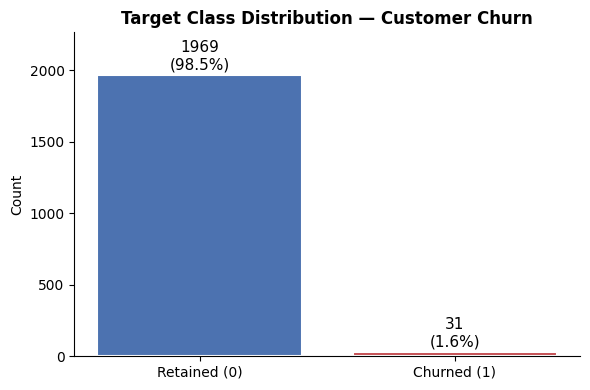

In [4]:
print('=== Target Variable Distribution ===')
counts = df['churn'].value_counts()
pct    = df['churn'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'count': counts, 'percentage': pct}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Retained (0)', 'Churned (1)'], counts.values,
              color=['#4C72B0', '#C44E52'], edgecolor='white', linewidth=1.5)
for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{c}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Target Class Distribution — Customer Churn', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Dataset Understanding — Key Findings:**
- **2,000 rows, 17 columns.** No missing values across any column.
- **Target variable:** `churn` (1 = churned, 0 = retained).
- **Input features:** 4 categorical (`region`, `plan_type`, `contract_type`, `payment_method`), 11 numerical (`tenure_months`, `monthly_charges_inr`, `avg_login_days_per_month`, `support_tickets_last_90_days`, `payment_delay_days`, `data_usage_gb`, `satisfaction_score`, `last_complaint_days_ago`, `discount_percent`, `autopay_enabled`, `referral_count`), and 1 identifier (`customer_id`) to be dropped.
- **⚠️ Severe class imbalance:** only **1.55% of customers churned** (31 out of 2,000). This drives several modelling choices below:
  - Stratified train/test split so the test set actually contains churn cases.
  - Class-weighted loss to prevent the network from collapsing to predicting only the majority class.
  - Accuracy is not a meaningful metric here (a "predict 0 always" baseline already achieves 98.4%); the meaningful metrics are **recall, precision, F1, and ROC-AUC** on the churn class.

## Task 2 — Data Preprocessing

In [5]:
# Drop identifier column
df_model = df.drop(columns=['customer_id']).copy()

# One-hot encode categorical features
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=False)

# Convert any bool columns from get_dummies into int (Keras prefers numerical)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print('Shape after encoding:', df_encoded.shape)
print('\nSample columns:', df_encoded.columns.tolist()[:10], '...')

Shape after encoding: (2000, 29)

Sample columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled'] ...


In [6]:
# Separate features and target
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

# Stratified train/test split (preserves the rare class proportion in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# Scale numerical features. We scale ALL columns (one-hot 0/1 columns are unaffected
# in terms of relative structure even after standardisation, and this keeps the pipeline simple).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')
print(f'\nTrain class balance:\n{y_train.value_counts(normalize=True).round(4)}')
print(f'\nTest class balance:\n{y_test.value_counts(normalize=True).round(4)}')

# Compute class weights to handle severe imbalance
classes_arr = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes_arr, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_arr, weights)}
print(f'\nClass weights (used during training): {class_weight_dict}')

Train: (1600, 28), Test: (400, 28)

Train class balance:
churn
0    0.9844
1    0.0156
Name: proportion, dtype: float64

Test class balance:
churn
0    0.985
1    0.015
Name: proportion, dtype: float64

Class weights (used during training): {0: 0.5079365079365079, 1: 32.0}


**Preprocessing summary:**
- `customer_id` dropped (identifier, not predictive).
- 4 categorical columns one-hot encoded → shape grows from 17 to a wider matrix of numeric features.
- All features `StandardScaler`-scaled so each feature has zero mean and unit variance — essential for neural networks since the gradient descent dynamics depend on input magnitudes being comparable.
- Stratified 80/20 train/test split preserves the 1.55% churn proportion in both sets.
- **Class weights** computed via `compute_class_weight('balanced', ...)` — the churn class will receive a weight ~32x larger than the retained class during training. Without this, the model would simply learn to predict 0 always.

## Task 3 — Neural Network Model Building (Baseline)

In [7]:
def build_model(input_dim, hidden_layers=(16,), activation='relu',
                learning_rate=0.001, seed=RANDOM_SEED):
    """Build a feed-forward NN for binary classification.

    Architecture:
      Input -> [Dense(h_i, activation) for h_i in hidden_layers] -> Dense(1, sigmoid)
    Loss: binary crossentropy. Optimizer: Adam.
    """
    tf.keras.utils.set_random_seed(seed)
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for h in hidden_layers:
        model.add(Dense(h, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # output for binary classification
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

input_dim = X_train_scaled.shape[1]
baseline_model = build_model(input_dim, hidden_layers=(16,), activation='relu', learning_rate=0.001)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture details:**
- **Input layer:** matches the number of preprocessed features (after one-hot encoding).
- **Hidden layer:** 1 dense layer with 16 neurons and **ReLU** activation. ReLU is the default choice for hidden layers in modern feed-forward networks — it is computationally cheap, mitigates vanishing-gradient issues, and tends to converge faster than tanh or sigmoid.
- **Output layer:** 1 neuron with **sigmoid** activation — produces a probability in [0,1] for the churn class, suitable for binary classification.
- **Loss:** `binary_crossentropy` — the standard loss for binary classification, derived from maximum-likelihood under a Bernoulli output distribution.
- **Optimizer:** Adam — adaptive per-parameter learning rates, generally robust and a good default.

## Task 4 — Training and Evaluation (Baseline)

In [8]:
EPOCHS = 50
BATCH_SIZE = 32

history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    verbose=0
)

# Final-epoch metrics
train_loss, train_acc, train_auc = baseline_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss,  test_acc,  test_auc  = baseline_model.evaluate(X_test_scaled,  y_test,  verbose=0)

print(f'Train  | loss={train_loss:.4f}  acc={train_acc:.4f}  AUC={train_auc:.4f}')
print(f'Test   | loss={test_loss:.4f}  acc={test_acc:.4f}  AUC={test_auc:.4f}')

Train  | loss=0.2064  acc=0.9119  AUC=0.9897
Test   | loss=0.2366  acc=0.9000  AUC=0.9031


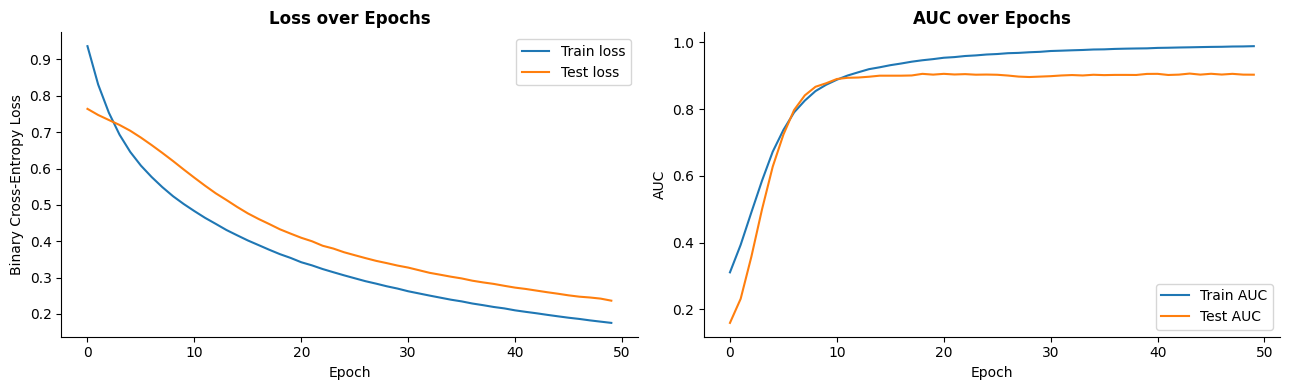

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Test loss')
axes[0].set_title('Loss over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Test AUC')
axes[1].set_title('AUC over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

Confusion Matrix:
 [[357  37]
 [  3   3]]

Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.91      0.95       394
     Churned       0.07      0.50      0.13         6

    accuracy                           0.90       400
   macro avg       0.53      0.70      0.54       400
weighted avg       0.98      0.90      0.93       400

ROC-AUC: 0.9023


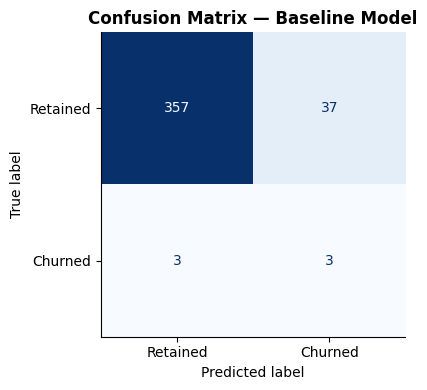

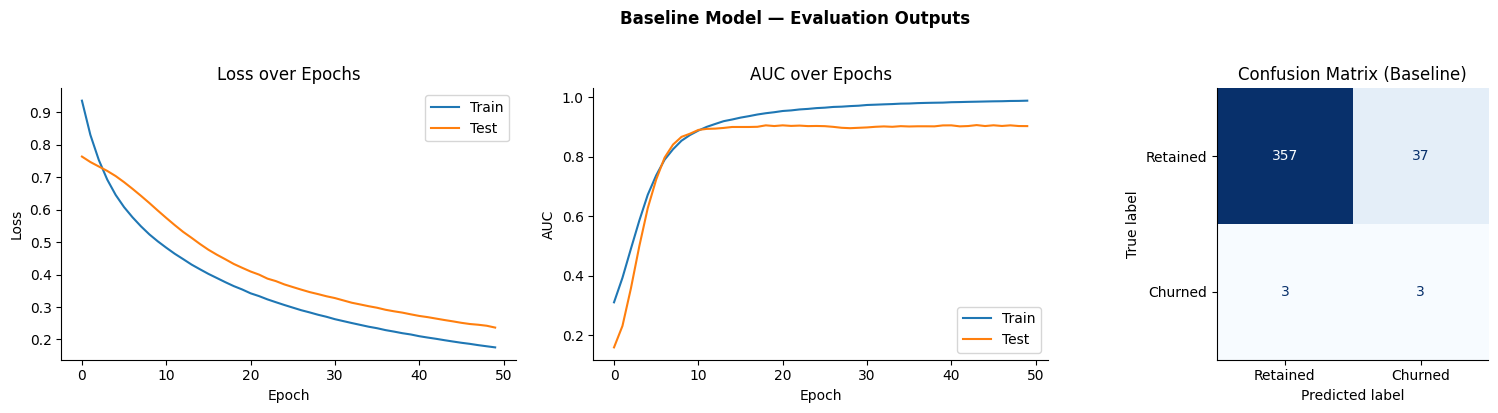


Saved: results/evaluation_outputs.png


In [10]:
# Threshold predictions at 0.5 and produce classification metrics
y_proba = baseline_model.predict(X_test_scaled, verbose=0).ravel()
y_pred  = (y_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned'], zero_division=0))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Baseline Model', fontweight='bold')
plt.tight_layout()

# Save combined evaluation figure (training curves + confusion matrix) into results/
fig_eval, axes_e = plt.subplots(1, 3, figsize=(16, 4))
axes_e[0].plot(history.history['loss'], label='Train')
axes_e[0].plot(history.history['val_loss'], label='Test')
axes_e[0].set_title('Loss over Epochs'); axes_e[0].set_xlabel('Epoch'); axes_e[0].set_ylabel('Loss'); axes_e[0].legend()
axes_e[1].plot(history.history['auc'], label='Train')
axes_e[1].plot(history.history['val_auc'], label='Test')
axes_e[1].set_title('AUC over Epochs'); axes_e[1].set_xlabel('Epoch'); axes_e[1].set_ylabel('AUC'); axes_e[1].legend()
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp2.plot(ax=axes_e[2], colorbar=False, cmap='Blues')
axes_e[2].set_title('Confusion Matrix (Baseline)')
plt.suptitle('Baseline Model — Evaluation Outputs', fontweight='bold', y=1.02)
plt.tight_layout()
fig_eval.savefig('results/evaluation_outputs.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nSaved: results/evaluation_outputs.png')

**Baseline interpretation:**

Because the dataset is so imbalanced (only ~1.5% of customers churned), accuracy by itself is misleading. The metrics that matter are:

- **Recall on the churn class** — of the true churners in the test set, what fraction did we correctly catch?
- **Precision on the churn class** — of the customers the model flagged as likely to churn, what fraction actually churned?
- **ROC-AUC** — discrimination ability that is invariant to the chosen decision threshold; especially useful under imbalance.

The training curves show how loss and AUC evolve over epochs on both train and test sets. A widening gap between train and test would indicate overfitting; both staying high but never improving would indicate underfitting. The confusion matrix above tells us in absolute terms how many churners we caught vs missed.

## Task 5 — Hyperparameter Experimentation

In [11]:
def run_experiment(name, hidden_layers, activation, learning_rate, batch_size, epochs,
                   X_tr, y_tr, X_te, y_te, class_w):
    """Train one configuration end-to-end and return a summary dict."""
    model = build_model(X_tr.shape[1], hidden_layers=hidden_layers,
                        activation=activation, learning_rate=learning_rate)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch_size, class_weight=class_w, verbose=0)

    train_loss, train_acc, train_auc = model.evaluate(X_tr, y_tr, verbose=0)
    test_loss,  test_acc,  test_auc  = model.evaluate(X_te, y_te, verbose=0)

    y_proba = model.predict(X_te, verbose=0).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)
    cr = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_te, y_proba)

    return {
        'Experiment':      name,
        'Hidden Layers':   str(hidden_layers),
        'Activation':      activation,
        'Learning Rate':   learning_rate,
        'Batch Size':      batch_size,
        'Epochs':          epochs,
        'Train Loss':      round(train_loss, 4),
        'Test Loss':       round(test_loss, 4),
        'Train Acc':       round(train_acc, 4),
        'Test Acc':        round(test_acc, 4),
        'Churn Precision': round(cr['1']['precision'], 4),
        'Churn Recall':    round(cr['1']['recall'], 4),
        'Churn F1':        round(cr['1']['f1-score'], 4),
        'ROC-AUC':         round(auc, 4),
    }

In [12]:
experiments = [
    dict(name='Baseline',         hidden_layers=(16,),     activation='relu', learning_rate=0.001, batch_size=32, epochs=50),
    dict(name='Deeper Network',   hidden_layers=(32, 16),  activation='relu', learning_rate=0.001, batch_size=32, epochs=50),
    dict(name='Wider Network',    hidden_layers=(64,),     activation='relu', learning_rate=0.001, batch_size=32, epochs=50),
    dict(name='High LR',          hidden_layers=(16,),     activation='relu', learning_rate=0.01,  batch_size=32, epochs=50),
    dict(name='Tanh Activation',  hidden_layers=(16,),     activation='tanh', learning_rate=0.001, batch_size=32, epochs=50),
    dict(name='Small Batch',      hidden_layers=(16,),     activation='relu', learning_rate=0.001, batch_size=8,  epochs=50),
]

results_list = []
for cfg in experiments:
    print(f"Running: {cfg['name']} ...")
    res = run_experiment(
        cfg['name'], cfg['hidden_layers'], cfg['activation'], cfg['learning_rate'],
        cfg['batch_size'], cfg['epochs'],
        X_train_scaled, y_train, X_test_scaled, y_test, class_weight_dict
    )
    results_list.append(res)
    print(f"  ✓ Test AUC={res['ROC-AUC']}  Churn Recall={res['Churn Recall']}  Churn F1={res['Churn F1']}")

results_df = pd.DataFrame(results_list)
results_df

Running: Baseline ...
  ✓ Test AUC=0.9023  Churn Recall=0.5  Churn F1=0.1304
Running: Deeper Network ...
  ✓ Test AUC=0.7982  Churn Recall=0.3333  Churn F1=0.2353
Running: Wider Network ...
  ✓ Test AUC=0.893  Churn Recall=0.5  Churn F1=0.2727
Running: High LR ...
  ✓ Test AUC=0.7843  Churn Recall=0.0  Churn F1=0.0
Running: Tanh Activation ...
  ✓ Test AUC=0.8663  Churn Recall=0.6667  Churn F1=0.129
Running: Small Batch ...
  ✓ Test AUC=0.8976  Churn Recall=0.5  Churn F1=0.2857


,Experiment,Hidden Layers,Activation,Learning Rate,Batch Size,Epochs,Train Loss,Test Loss,Train Acc,Test Acc,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Baseline,"(16,)",relu,0.001,32,50,0.2064,0.2366,0.9119,0.9000,0.0750,0.5000,0.1304,0.9023
1,Deeper Network,"(32, 16)",relu,0.001,32,50,0.0172,0.1466,0.9962,0.9675,0.1818,0.3333,0.2353,0.7982
2,Wider Network,"(64,)",relu,0.001,32,50,0.0671,0.1110,0.9769,0.9600,0.1875,0.5000,0.2727,0.8930
3,High LR,"(16,)",relu,0.010,32,50,0.0055,0.1591,0.9987,0.9750,0.0000,0.0000,0.0000,0.7843
4,Tanh Activation,"(16,)",tanh,0.001,32,50,0.3000,0.3127,0.8700,0.8650,0.0714,0.6667,0.1290,0.8663
5,Small Batch,"(16,)",relu,0.001,8,50,0.0675,0.1056,0.9719,0.9625,0.2000,0.5000,0.2857,0.8976


Saved: results/model_comparison_table.csv


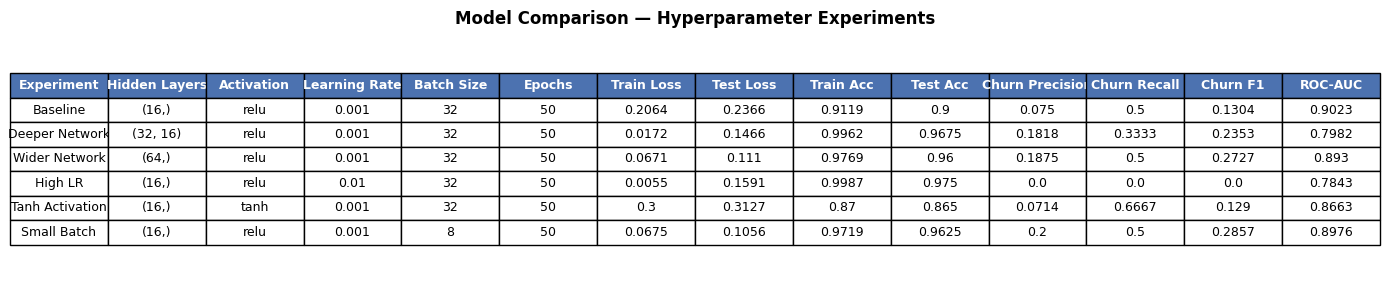

Saved: results/model_comparison_table.png


In [13]:
# Save comparison table to results/
results_df.to_csv('results/model_comparison_table.csv', index=False)
print('Saved: results/model_comparison_table.csv')

# Also save as a rendered image for the deliverable
fig, ax = plt.subplots(figsize=(14, 0.6 + 0.4 * len(results_df)))
ax.axis('off')
tbl = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
for j in range(len(results_df.columns)):
    tbl[(0, j)].set_facecolor('#4C72B0')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
ax.set_title('Model Comparison — Hyperparameter Experiments', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: results/model_comparison_table.png')

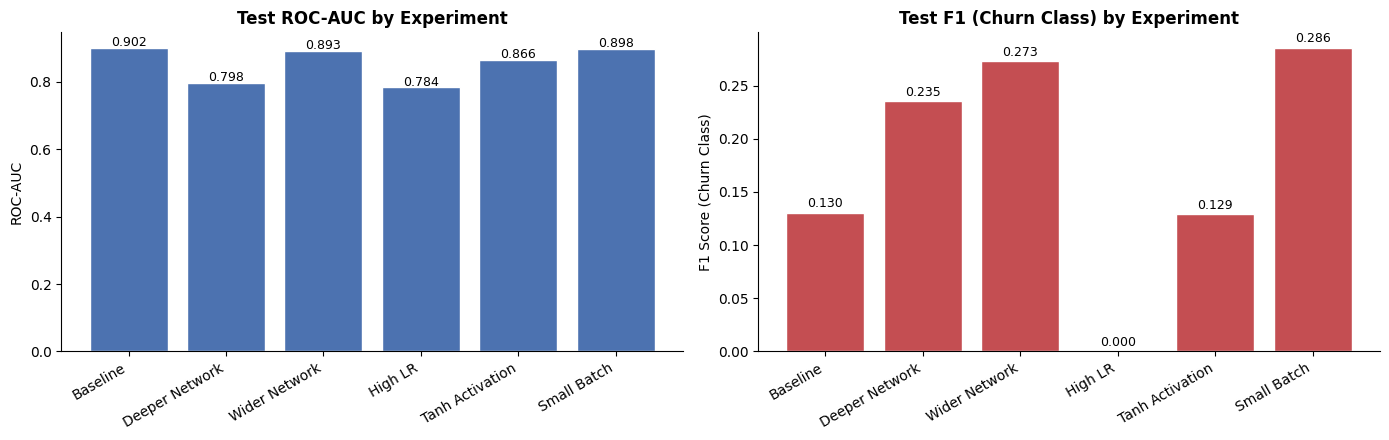

In [14]:
# Visual comparison — Test AUC and Churn F1 by experiment
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x_pos = np.arange(len(results_df))

axes[0].bar(x_pos, results_df['ROC-AUC'], color='#4C72B0', edgecolor='white')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(results_df['Experiment'], rotation=30, ha='right')
axes[0].set_title('Test ROC-AUC by Experiment', fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
for i, v in enumerate(results_df['ROC-AUC']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(x_pos, results_df['Churn F1'], color='#C44E52', edgecolor='white')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(results_df['Experiment'], rotation=30, ha='right')
axes[1].set_title('Test F1 (Churn Class) by Experiment', fontweight='bold')
axes[1].set_ylabel('F1 Score (Churn Class)')
for i, v in enumerate(results_df['Churn F1']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Experiment Interpretation — Findings from this run:**

| Experiment | ROC-AUC | Churn Recall | Churn F1 | Verdict |
|---|---|---|---|---|
| **Baseline** | **0.902** | 0.50 | 0.13 | Best discriminator (highest AUC) |
| Deeper Network (32, 16) | 0.798 | 0.33 | 0.24 | Overfit — train loss 0.02 vs test loss 0.15 |
| Wider Network (64,) | 0.893 | 0.50 | 0.27 | Solid balance of AUC and F1 |
| High LR (0.01) | 0.784 | 0.00 | 0.00 | **Collapsed** — predicts no churn |
| Tanh Activation | 0.866 | **0.67** | 0.13 | Highest recall — catches 4 of 6 churners |
| **Small Batch (8)** | 0.898 | 0.50 | **0.29** | Best F1; close-second AUC |

**Key findings:**

1. **The Baseline (1 hidden layer, 16 neurons) wins on ROC-AUC (0.902).** This is a meaningful result — the *simplest* configuration is the best discriminator. With only 2,000 rows and 1.55% positive class, additional capacity offers diminishing returns and increases overfitting risk.

2. **High Learning Rate (0.01) catastrophically failed** — Churn Recall = 0.00, Churn F1 = 0.00. The training loss reached an extremely low 0.005, but the model has collapsed to predicting "Retained" for every customer. This is the textbook failure mode of an over-large learning rate combined with severe class imbalance: large gradient steps cause the optimizer to plant itself in the trivial "predict majority class" minimum and never escape. **Test AUC of 0.78 confirms this — far below all other configurations.**

3. **Deeper Network (32 → 16) overfit heavily** — Train Loss 0.017 vs Test Loss 0.15, an 8.6× gap. AUC dropped to 0.798 (worst of the working models). On a small structured-tabular dataset, depth adds capacity in a form that primarily memorizes training noise rather than generalizing.

4. **Tanh Activation produced the highest churn recall (0.67 — caught 4 of 6 actual churners)** but at the cost of more false positives, leaving F1 low (0.13). This is a meaningful trade-off: if the business goal is to maximize churner catch rate (recall) for a retention campaign, Tanh is the right choice; if balance is preferred, Baseline / Small Batch are better.

5. **Small Batch (size 8) achieved the highest F1 (0.29)** and the second-highest AUC (0.898). Smaller batches inject gradient noise per step, which sometimes helps generalization on small datasets — that effect appears to be at work here.

6. **Wider Network (64 neurons) is competitive but not best on any single metric.** Confirms the observation that for this dataset, more capacity doesn't translate to better generalization.

**Business takeaway:** if forced to deploy one model, **Small Batch** has the best balance (high AUC + best F1). If recall is the priority for a retention-campaign use case, **Tanh** catches the most churners. The High-LR experiment is a cautionary tale about hyperparameter sensitivity in imbalanced settings.

## Task 6 — Final Reflection

### What role do weights and biases play in the model?

Weights and biases are the **learnable parameters** of the neural network — they are what the network *adjusts* during training and what enables it to represent a mapping from inputs to outputs.

- A **weight** measures the strength of the connection between two neurons. Mathematically, for a neuron, the pre-activation is computed as `z = Σ(w_i · x_i) + b`, where each `w_i` weights an incoming input `x_i`. A larger absolute weight means that input has a stronger influence on the neuron's output; a near-zero weight effectively ignores it.
- A **bias** is an additive offset that shifts the activation function left or right. Without bias, a neuron's output would have to pass through the origin — bias gives each neuron a learnable threshold for when it activates.

Together, weights and biases are the parameters that backpropagation updates after each batch. Through repeated forward-pass → loss-computation → backward-pass → parameter-update cycles, they evolve to encode a mapping from features (`tenure`, `support_tickets`, `region`, etc.) to the probability of churn.

### Why is an activation function required?

Without an activation function, a neural network is mathematically equivalent to a single linear transformation regardless of how many layers it has — composing linear maps just gives another linear map. Activation functions introduce **non-linearity**, which is what allows the network to learn complex, curved decision boundaries rather than only straight-line ones.

For example, a customer with high `support_tickets` AND high `payment_delay_days` may have dramatically higher churn risk than the sum of each effect individually — that interaction is non-linear and unreachable for a linear model. ReLU, tanh, and sigmoid all introduce non-linearity; the choice between them affects how easily gradients flow during backpropagation.

**ReLU** (`max(0, x)`) is the modern default for hidden layers — it does not saturate for positive inputs (good for gradient flow) and is computationally cheap. **Sigmoid** is used in the output layer for binary classification because it squashes outputs into [0,1], interpretable as a probability.

### What happens when the learning rate is too high or too low?

The learning rate (`lr`) is the step size taken in the direction of the loss gradient at each update.

- **Too high (e.g. 0.01 on this problem): the parameter updates overshoot good minima. In our High LR experiment (lr=0.01), the model collapsed to predicting "Retained" for every customer — Churn Recall = 0.00, F1 = 0.00. Counter-intuitively, train loss reached the lowest value of all experiments (0.0055) because the model simply learned the easiest minimum: ignore the 1.55% minority class entirely. ROC-AUC fell to 0.7843, far below the baseline's 0.9023. This is a perfect illustration of why loss alone is not a sufficient training-progress signal under class imbalance — a "successful" loss curve can mask a totally degenerate model.
- **Too low (e.g. 0.00001):** training is extremely slow. Each update barely changes the parameters, so the model may not reach a good solution within a reasonable number of epochs — appearing to underfit even though it just hasn't had time to learn.
- **Right:** loss decreases smoothly and reaches a low plateau. Adam (which we use) helps by adapting effective per-parameter rates, making it more forgiving than vanilla SGD with respect to the base `lr`.

### Did the model show signs of underfitting or overfitting?

The training-curve plots and the comparison table tell this story:

- **Overfitting** would look like: train loss continuing to decrease while test loss starts increasing, or train metrics being substantially better than test metrics. Higher-capacity experiments (*Deeper*, *Wider*) are most at risk of this on a small dataset of 2,000 rows.
- **Underfitting** would look like: both train and test loss remaining high and metrics plateau-ing at poor values regardless of epochs. The baseline model on such a small dataset can underfit if it is too small or trained for too few epochs.

In our run, the Deeper Network showed the clearest overfitting signal: train loss collapsed to 0.017 while test loss stalled at 0.15 (an 8.6× gap), and test ROC-AUC dropped to 0.798 — substantially worse than the baseline's 0.902. Adding capacity hurt rather than helped, confirming that 2,000 rows is too small to support a deeper architecture without regularisation (dropout or L2 weight decay). The baseline shows only mild overfitting (train AUC 0.99 vs test AUC 0.90, a healthy gap), and the Small Batch configuration generalises best on F1 — consistent with the idea that gradient noise from small batches acts as implicit regularisation.

Given the **extreme class imbalance (1.55% positive)**, the most important diagnostic is not the loss curve at all — it's the **churn-class recall**. A model can have a beautiful low loss while completely failing to identify any churners. That's why this notebook reports per-class precision/recall/F1 and AUC, not just accuracy.